In [ ]:
pip install skyfield

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 20.7 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import os
from skyfield.api import load, wgs84
from scipy.linalg import block_diag
from scipy import linalg

Preparation of satelites, getting data from celestrak, choosing number of satellites

In [ ]:
print("Loading actual satellite map")
stations_url = 'https://celestrak.org/NORAD/elements/gps-ops.txt'
satellites = load.tle_file(stations_url)

my_sats = satellites[:6]
num_sats = len(my_sats)
print(f"Using satellites: {[sat.name for sat in my_sats]}")
dt = 1.0

Loading actual satellite map


[#################################] 100% gps-ops.txt


Using satellites: ['GPS BIIR-2  (PRN 13)', 'GPS BIIR-5  (PRN 22)', 'GPS BIIR-8  (PRN 16)', 'GPS BIIR-11 (PRN 19)', 'GPS BIIR-13 (PRN 02)', 'GPS BIIRM-1 (PRN 17)']


Data generation

In [ ]:
def enu2ecef(enu_vector, ref_ecef, lat_deg, lon_deg):
    """
    Auxiliar fuction for converting ENU to ECEF.
    """
    lon_deg = (lon_deg + 180) % 360 - 180

    phi = np.radians(lat_deg)
    lam = np.radians(lon_deg)

    R_enu2ecef = np.array([
        [-np.sin(lam), -np.sin(phi)*np.cos(lam), np.cos(phi)*np.cos(lam)],
        [ np.cos(lam), -np.sin(phi)*np.sin(lam), np.cos(phi)*np.sin(lam)],
        [           0,              np.cos(phi),             np.sin(phi)]
    ])

    return ref_ecef + (R_enu2ecef @ enu_vector)

In [ ]:
def ecef2enu(ecef_vector, ref_ecef, lat_deg, lon_deg):
    """
    Converts ECEF coordinates back to local ENU coordinates.
    """
    lon_deg = (lon_deg + 180) % 360 - 180
    phi = np.radians(lat_deg)
    lam = np.radians(lon_deg)

    R_enu2ecef = np.array([
        [-np.sin(lam), -np.sin(phi)*np.cos(lam), np.cos(phi)*np.cos(lam)],
        [ np.cos(lam), -np.sin(phi)*np.sin(lam), np.cos(phi)*np.sin(lam)],
        [           0,              np.cos(phi),             np.sin(phi)]
    ])

    R_ecef2enu = R_enu2ecef.T

    return R_ecef2enu @ (ecef_vector - ref_ecef)

In [ ]:
def get_data_vehicle(my_sats, route_list, speed_kmh=50.0, dt=1.0, start_lat=60.1841, start_lon=24.8301, start_alt=20.0):
    """
    Generates data for the vehicle.

    Parameters:
    - my_sats (list): List of Skyfield satellite objects.
    - route_list (list): List of tuples representing route segments.
    - speed_kmh (float): Speed of the vehicle in kilometers per hour.
    - dt (float): Time step in seconds.
    - start_lat (float): Starting latitude in degrees.
    - start_lon (float): Starting longitude in degrees.
    - start_alt (float): Starting altitude in meters.

    Returns:
    - USER_Pos_ecef (numpy.ndarray): Array of user position in ECEF coordinates.
    - SV_Pos_ecef (numpy.ndarray): Array of satellite positions in ECEF coordinates.
    - USER_Pos_enu (numpy.ndarray): Array of user position in ENU coordinates.
    - t_array (numpy.ndarray): Array of time values.

    """
    ts = load.timescale()

    # starting position in ECEF
    ref_ecef = wgs84.latlon(start_lat, start_lon, start_alt).itrs_xyz.m


    speed_ms = speed_kmh / 3.6
    D_step = speed_ms * dt

    # How many steps will each part of the route take
    steps_per_seg = []
    for seg in route_list:
        distance = abs(seg[1])
        steps = int(np.floor(distance / speed_ms))
        steps_per_seg.append(steps)

    num_steps = sum(steps_per_seg)

    t_array = ts.utc(2026, 4, 1, 14, 0, range(num_steps))

    USER_Pos_enu = np.zeros((num_steps, 3))
    USER_Pos_ecef = np.zeros((num_steps, 3))

    # Vehicle data generation, taken from gps-help, gps_helper.py
    k_step = 0
    current_enu = np.zeros(3)

    for n in range(len(route_list)):
        direction = route_list[n][0]
        sign = np.sign(route_list[n][1])

        for m in range(steps_per_seg[n]):
            if direction == 'e':
                current_enu[0] += D_step * sign
            elif direction == 'n':
                current_enu[1] += D_step * sign
            elif direction == 'u':
                current_enu[2] += D_step * sign
            else:
                print("Route direction must be 'e', 'n', or 'u'")

            USER_Pos_enu[k_step, :] = current_enu
            USER_Pos_ecef[k_step, :] = enu2ecef(current_enu, ref_ecef, start_lat, start_lon)
            k_step += 1

    # Satellite position generation
    num_sats = len(my_sats)
    SV_Pos_ecef = np.zeros((num_sats, 3, num_steps))

    for n, sat in enumerate(my_sats):
        geocentric = sat.at(t_array)
        SV_Pos_ecef[n, :, :] = geocentric.position.m

    return USER_Pos_ecef, SV_Pos_ecef, USER_Pos_enu, t_array

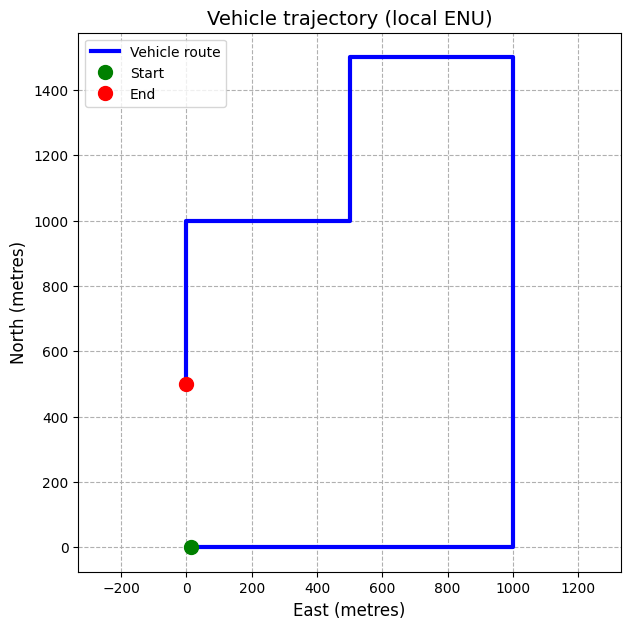

In [ ]:
# Route definition
route = [('e', 1000), ('n', 1500), ('e', -500), ('n', -500), ('e', -500), ('n', -500)]

USER_Pos_ecef, SV_Pos_ecef, USER_Pos_enu, t_array = get_data_vehicle(
    my_sats,
    route_list=route,
    speed_kmh=50.0
)


plt.figure(figsize=(7, 7))
plt.plot(USER_Pos_enu[:, 0], USER_Pos_enu[:, 1], 'b-', linewidth=3, label='Vehicle route')
plt.plot(USER_Pos_enu[0, 0], USER_Pos_enu[0, 1], 'go', markersize=10, label='Start')
plt.plot(USER_Pos_enu[-1, 0], USER_Pos_enu[-1, 1], 'ro', markersize=10, label='End')

plt.title('Vehicle trajectory (local ENU)', fontsize=14)
plt.xlabel('East (metres)', fontsize=12)
plt.ylabel('North (metres)', fontsize=12)
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.legend()
plt.savefig('Trajectory.eps', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
def sv_user_traj_3d(sv_pos, user_pos, sv_names, ele=10, azim=20):
    """
    3D visualization of the Earth, satellite orbits, and the user trajectory.
    Adapted from gps-helper.

    sv_pos: Satellite positions array of shape (num_sats, 3, num_steps)
    user_pos: User positions array of shape (num_steps, 3)
    sv_names: List of satellite names (e.g., ['PRN 03', 'PRN 09', ...])
    """
    radius = 6371669.9 # Earth radius in meters

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Draw the Earth sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, rstride=4, cstride=4, color='b', linewidth=0, alpha=0.1)

    # Draw the satellite trajectories
    num_sats = sv_pos.shape[0]
    for n in range(num_sats):
        ax.plot(sv_pos[n, 0, :], sv_pos[n, 1, :], sv_pos[n, 2, :], label=sv_names[n])

    # Draw the user trajectory
    ax.plot(user_pos[:, 0], user_pos[:, 1], user_pos[:, 2], 'r', linewidth=3.0, label='USER')

    ax.set_xlim3d(-2.5e7, 2.5e7)
    ax.set_ylim3d(-2.5e7, 2.5e7)
    ax.set_zlim3d(-1e7, 2.5e7)
    ax.set_xlabel('X ECEF (m)')
    ax.set_ylabel('Y ECEF (m)')
    ax.set_zlabel('Z ECEF (m)')
    ax.set_title('SV and USER Trajectories')
    ax.view_init(elev=ele, azim=azim)
    plt.legend(loc='upper right')
    plt.savefig('Worlds_visu.eps', dpi=400, bbox_inches='tight')
    plt.show()

In [ ]:
satellite_names = [sat.name for sat in my_sats]


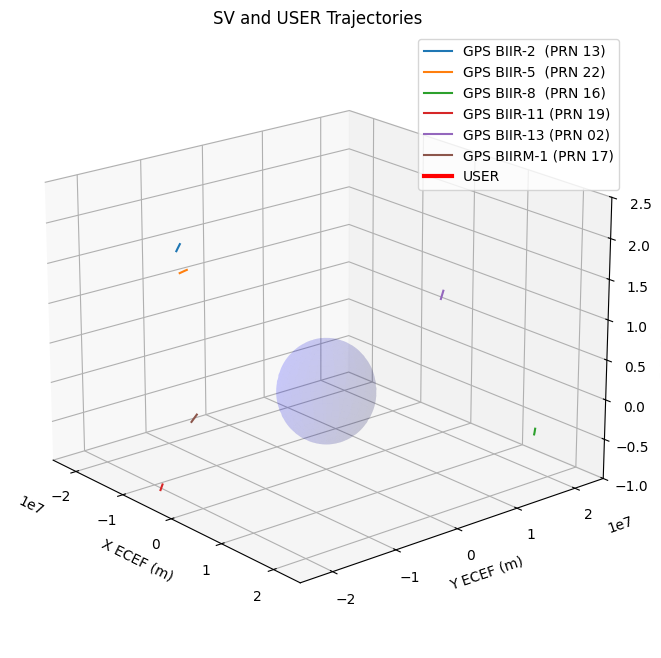

In [ ]:
sv_user_traj_3d(SV_Pos_ecef, USER_Pos_ecef, satellite_names, ele=20, azim=-40)

In [ ]:
def noisy_pseudo_ranges(SV_Pos_ecef, USER_Pos_ecef, clock_bias=100000.0, clock_drift=10.0, std_noise=5.0):

  time_steps = USER_Pos_ecef.shape[0]
  num_sattelites = SV_Pos_ecef.shape[0]

  pseudo_ranges = np.zeros((num_sattelites, time_steps))

  for n in range(time_steps):
    for m in range(num_sattelites):
      current_bias = clock_bias + clock_drift * n
      pseudo_ranges[m, n] = np.sqrt(np.sum((SV_Pos_ecef[m, :, n] - USER_Pos_ecef[n, :])**2))+current_bias+std_noise*np.random.randn()

  return pseudo_ranges

In [ ]:
# m = [x, v_x, y, v_y, z, v_z, bias, drift]

m_0 = np.zeros(8)
initial_guess_error = 100.0
m_0[0] = USER_Pos_ecef[0, 0] + np.random.normal(0, initial_guess_error)
m_0[2] = USER_Pos_ecef[0, 1] + np.random.normal(0, initial_guess_error)
m_0[4] = USER_Pos_ecef[0, 2] + np.random.normal(0, initial_guess_error)

P_0 = np.eye(8)

# setting uncertainties
P_0[0:3, 0:3] *= 1e5
P_0[3:6, 3:6] *= 1e3
P_0[6, 6] *= 1e7
P_0[7, 7] *= 1e3

A_cv = np.array([[1, dt],
                 [0, 1]])

A = block_diag(A_cv, A_cv, A_cv, A_cv)

sigma_xyz = 0.5

Q_xyz = sigma_xyz**2 * np.array([[dt**3/3, dt**2/2],
                                 [dt**2/2, dt]])

S_f = 36.0
S_g = 0.01

Q_b = np.array([[S_f*dt + S_g*dt**3/3, S_g*dt**2 / 2],
                [S_g*dt**2 / 2, S_g * dt]])

Q = block_diag(Q_xyz, Q_xyz, Q_xyz, Q_b)

sigma_rho = 5.0

R = np.eye(num_sats) * (sigma_rho**2)


In [ ]:
def get_h_x(m, current_sats):

    num_sats = current_sats.shape[0]
    expected_ranges = np.zeros(num_sats)

    user_pos = np.array([m[0], m[2], m[4]])
    clock_bias = m[6]

    for j in range(num_sats):
        sat_pos = current_sats[j, :]
        expected_ranges[j] = np.sqrt(np.sum((sat_pos - user_pos)**2)) + clock_bias

    return expected_ranges

In [ ]:
def get_H(m, current_sats):

    num_sats = current_sats.shape[0]
    H = np.zeros((num_sats, 8))

    user_pos = np.array([m[0], m[2], m[4]])

    for j in range(num_sats):
        sat_pos = current_sats[j, :]

        dist = np.sqrt(np.sum((sat_pos - user_pos)**2))


        H[j, 0] = (user_pos[0] - sat_pos[0]) / dist
        H[j, 2] = (user_pos[1] - sat_pos[1]) / dist
        H[j, 4] = (user_pos[2] - sat_pos[2]) / dist
        H[j, 6] = 1.0

    return H

In [ ]:
def EKF(A, Q, R, m_0, P_0, observations, SV_Pos_ecef):

    steps = observations.shape[1]

    kf_m = np.zeros((steps, 8))
    kf_P = np.zeros((steps, 8, 8))

    m = m_0
    P = P_0

    for i in range(steps):
        y = observations[:, i]
        current_sats = SV_Pos_ecef[:, :, i]

        m = A @ m
        P = A @ P @ A.T + Q

        h_x = get_h_x(m, current_sats)
        H = get_H(m, current_sats)

        S = H @ P @ H.T + R

        K = linalg.solve(S.T, H @ P, assume_a="pos").T

        m = m + K @ (y - h_x)
        P = P - K @ S @ K.T

        kf_m[i, :] = m
        kf_P[i, :] = P
    return kf_m, kf_P

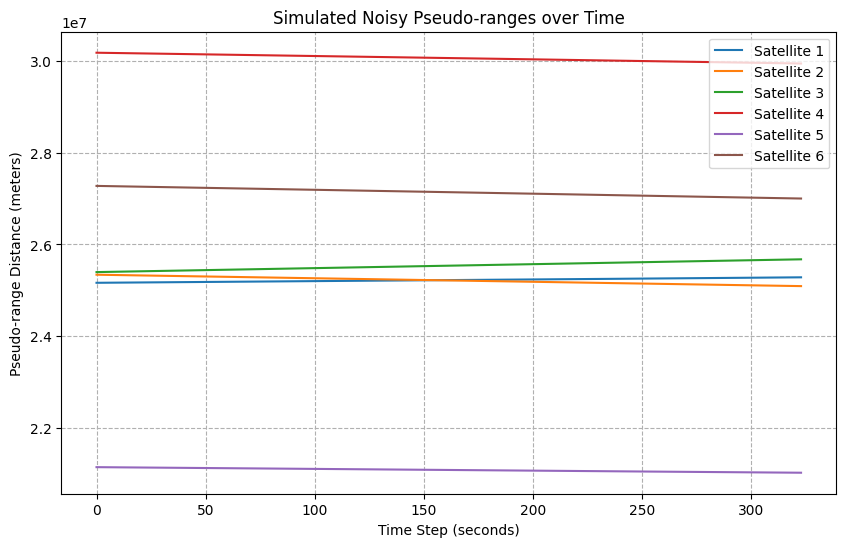

In [ ]:
pseudo_ranges = noisy_pseudo_ranges(SV_Pos_ecef, USER_Pos_ecef)
num_sats = pseudo_ranges.shape[0]

plt.figure(figsize=(10, 6))

for m in range(num_sats):
    plt.plot(pseudo_ranges[m, :], label=f'Satellite {m+1}')

plt.title('Simulated Noisy Pseudo-ranges over Time')
plt.xlabel('Time Step (seconds)')
plt.ylabel('Pseudo-range Distance (meters)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [ ]:
Z_measurements = noisy_pseudo_ranges(SV_Pos_ecef, USER_Pos_ecef)

estimated_states, estimated_covariances = EKF(A, Q, R, m_0, P_0, Z_measurements, SV_Pos_ecef)

estimated_positions_ecef = estimated_states[:, [0, 2, 4]]

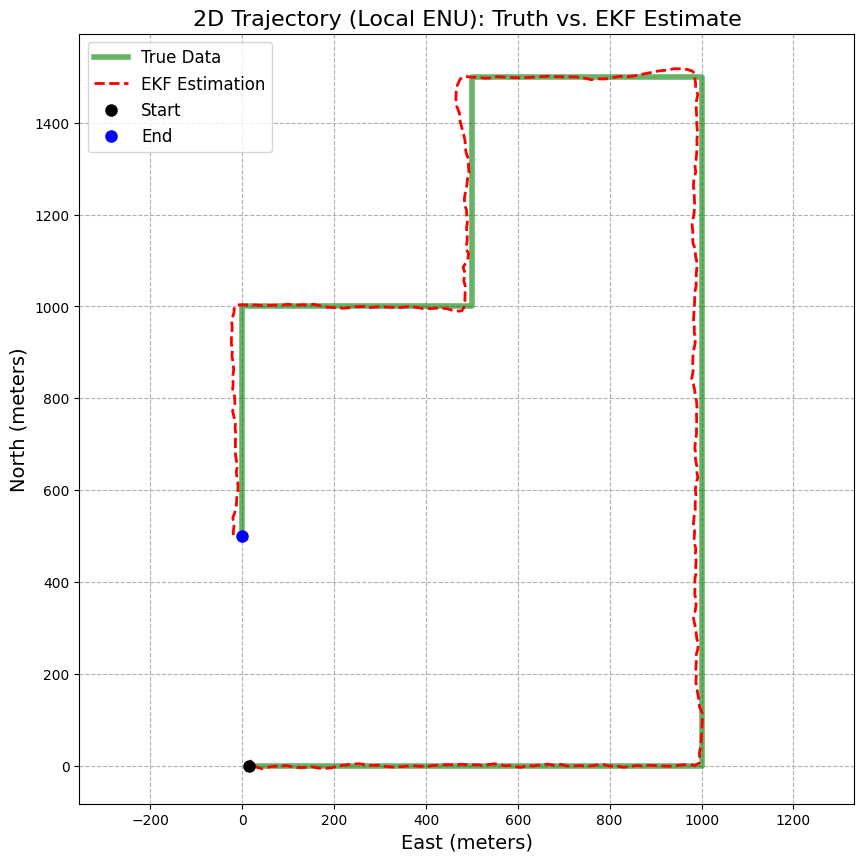

In [ ]:
start_lat = 60.1841
start_lon = 24.8301
ref_ecef = USER_Pos_ecef[0, :]

estimated_positions_enu = np.zeros_like(estimated_positions_ecef)

for i in range(estimated_positions_ecef.shape[0]):
    estimated_positions_enu[i, :] = ecef2enu(estimated_positions_ecef[i, :], ref_ecef, start_lat, start_lon)

plt.figure(figsize=(10, 10))

plt.plot(USER_Pos_enu[:, 0], USER_Pos_enu[:, 1], 'g-', linewidth=4, label='True Data', alpha=0.6)

plt.plot(estimated_positions_enu[:, 0], estimated_positions_enu[:, 1], 'r--', linewidth=2, label='EKF Estimation')

plt.plot(USER_Pos_enu[0, 0], USER_Pos_enu[0, 1], 'ko', markersize=8, label='Start')
plt.plot(USER_Pos_enu[-1, 0], USER_Pos_enu[-1, 1], 'bo', markersize=8, label='End')

plt.title('2D Trajectory (Local ENU): Truth vs. EKF Estimate', fontsize=16)
plt.xlabel('East (meters)', fontsize=14)
plt.ylabel('North (meters)', fontsize=14)
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.legend(fontsize=12)
plt.savefig('Kalman_filtering.eps', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
error_x = USER_Pos_ecef[:, 0] - estimated_positions_ecef[:, 0]
error_y = USER_Pos_ecef[:, 1] - estimated_positions_ecef[:, 1]
error_z = USER_Pos_ecef[:, 2] - estimated_positions_ecef[:, 2]

squared_errors = error_x**2 + error_y**2 + error_z**2

mse = np.mean(squared_errors)

rmse = np.sqrt(mse)

print(f"Total RMSE (for the entire route): {rmse:.2f} meters")

Total RMSE (for the entire route): 8.07 meters


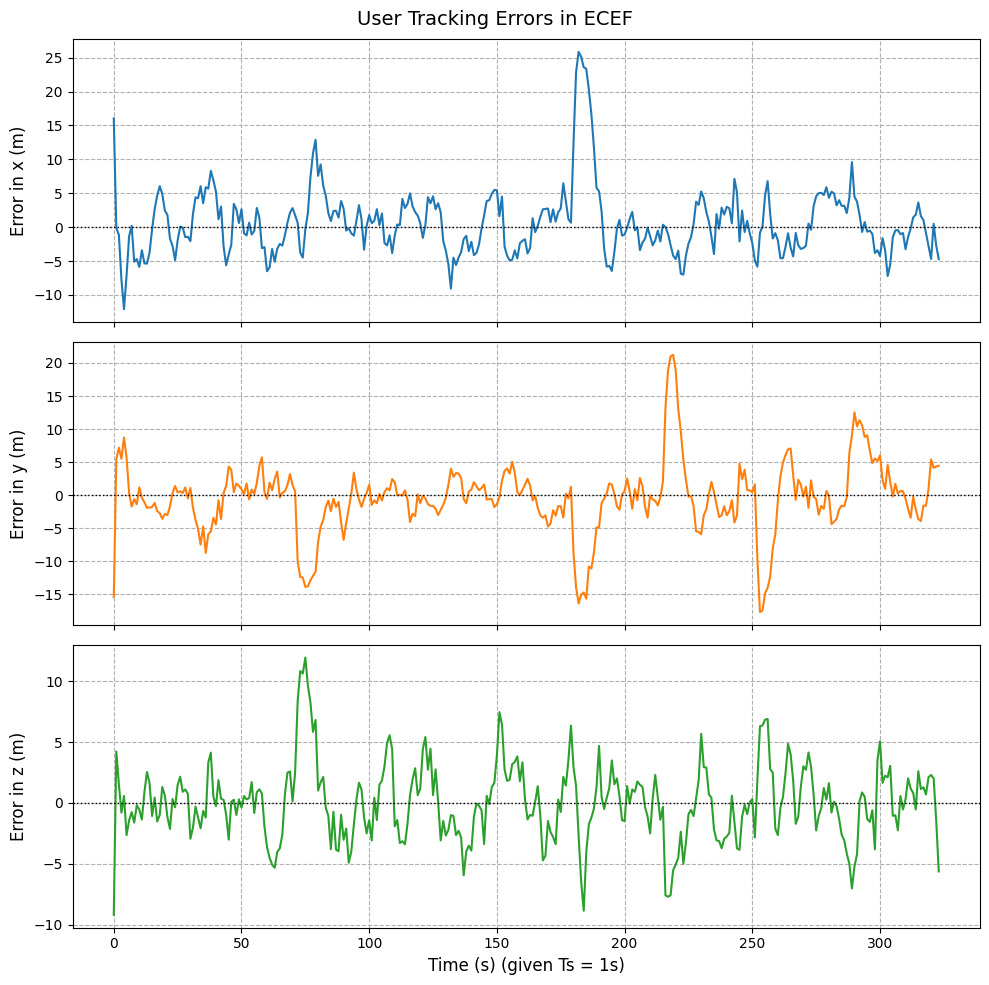

In [ ]:
ignore = 0

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(error_x[ignore:], color='#1f77b4', linewidth=1.5)
axs[0].set_ylabel('Error in x (m)', fontsize=12)
axs[0].grid(True, linestyle='--')
axs[0].axhline(0, color='black', linewidth=1, linestyle=':')

axs[1].plot(error_y[ignore:], color='#ff7f0e', linewidth=1.5)
axs[1].set_ylabel('Error in y (m)', fontsize=12)
axs[1].grid(True, linestyle='--')
axs[1].axhline(0, color='black', linewidth=1, linestyle=':')

axs[2].plot(error_z[ignore:], color='#2ca02c', linewidth=1.5)
axs[2].set_ylabel('Error in z (m)', fontsize=12)
axs[2].set_xlabel('Time (s) (given Ts = 1s)', fontsize=12)
axs[2].grid(True, linestyle='--')
axs[2].axhline(0, color='black', linewidth=1, linestyle=':')

plt.suptitle('User Tracking Errors in ECEF', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('errors.eps', dpi=400, bbox_inches='tight')
plt.show()